<a href="https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started with Google Data Commons for Knowledge Discovery


**Part 1 of 3: Basics of the Knowledge Graph and API**

---

Welcome to the **Google Data Commons for Knowledge Discovery** tutorial series! This is the **first** of three notebooks that guide you through accessing and exploring the rich, structured data provided by **Google Data Commons (GDC)** using Python.

Google Data Commons organizes public datasets into a **Knowledge Graph (KG)**—a network of interconnected entities and their relationships. You’ll learn how to query and traverse this graph to extract meaningful insights using official APIs.

---

## 🔍 What You'll Learn in This Notebook

- What a knowledge graph is and how GDC uses it
- How to identify and query entities using their DCIDs
- How to retrieve properties and relationship triples
- How to visualize entity relationships using NetworkX

---

📚 **Tutorial Series Overview**:

1. ✅ **[Basics of Data Commons and Knowledge Graphs](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb)** (this notebook)  
* Understand the structure of the Data Commons Knowledge Graph

* Use key API functions like `get_triples()` and `get_property_values()`

* Visualize relationships between entities with NetworkX
2. 📈 **[Building and Visualizing Emissions Datasets](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb)**  
* Build a time series dataset using `get_stat_series()`

* Combine emissions with population and location metadata

* Visualize environmental trends with `Seaborn` and `Plotly`
3. 🌐 **[Interconnectivity and Event Exploration in GDC](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/03_exploring_graphs.ipynb)**
* Traverse entity relationships across time and geography

* Explore disaster and climate event data

* Build graph-based visualizations of interconnected nodes

---

> **This notebook is self-contained and beginner-friendly. You do **not** need prior experience with knowledge graphs—but basic Python and Pandas will help.**


## ⚙️ Setup: Installing Required Packages

If you're running this notebook in **Google Colab**, run the following cells to install the required packages.

If you're working in a **local environment**, install them using `pip` in your terminal before launching Jupyter:

```bash
pip install datacommons datacommons_pandas pygraphviz
```


```python
# 📦 Install packages (Google Colab only)
!apt-get install -y graphviz libgraphviz-dev pkg-config
!pip install datacommons datacommons_pandas pygraphviz

# 📊 Set notebook visuals
%config InlineBackend.figure_format = 'retina'
```

In [1]:
!pip install datacommons
%config InlineBackend.figure_format = 'retina'


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.1 MB/s eta 0:00:00


# Understanding the Data Commons Knowledge Graph

## Section 1:  What Is Google Data Commons?

## 🧠 What Is Google Data Commons?

[Google Data Commons](https://datacommons.org/) is an open-source platform that organizes public datasets into a unified **Knowledge Graph (KG)**. A Knowledge Graph connects facts using **nodes (entities)** and **edges (relationships)**, much like a semantic network.

For example:
- **Entities**: A country, city, storm, or dataset variable like “Annual Carbon Emissions”
- **Relationships**: "located in", "affected by", or "has population"

This structure allows you to query complex data relationships easily. Think of it as a smart database that understands how different concepts relate to each other.

---

### 💡 Why is this useful?

- 🧩 You can combine data from across sources and domains (like EPA + Census)
- 🔎 You can programmatically retrieve data using a clean, unified API
- 📊 You can explore data **as a graph**—not just as rows in a table



You can find and explore information about entities and knowledge graph in [Knowledge Graph Explorer](https://datacommons.org/browser/)

## Introduction to Data Commons

## 🧱 How Data Commons Uses a Knowledge Graph

Google Data Commons organizes information using the structure of a **Knowledge Graph (KG)**—a network made up of:
- **Nodes** (also called **entities**) that represent real-world things like states, storms, people, or economic indicators.
- **Edges** (also called **relationships**) that describe how those entities are connected, like “located in”, “affected by”, or “has population”.
- **Properties** that describe metadata about the entities themselves.

---

### 🔄 Think of it like this:

Every fact in Data Commons is represented as a **triple**:  

```
[Subject] — [Relationship] —> [Object]
```

For example:

```
"California" — has population → "39 million" "California" — located in → "United States" "Storm Event" — affectedPlace → "California"

```




Each **entity** in the graph is uniquely identified by a **DCID** (Data Commons ID), such as `geoId/06` for California or `country/USA` for the United States.

---

## 🗺️ Visualizing the Structure (Schema Diagram)

Here’s a simplified schema showing how different entities relate to one another:




```
                     ┌────────────────┐
                     │  country/USA   │
                     └──────┬─────────┘
                            │ containedInPlace
                            ▼
                     ┌────────────────┐
                     │  geoId/06      │   ← California (State)
                     └────┬────┬──────┘
                          │    │
        ┌─────────────────┘    └────────────────────┐
        ▼                                            ▼
┌──────────────────────┐                     ┌────────────────────────┐
│ Annual_Emissions_CO2 │                     │ stormEvent/nws123456   │
│  (Statistical Var)   │                     │     (Specific Event)   │
└────────────┬─────────┘                     └────────────┬───────────┘
             │                                                   │
             │ measuredValue                                     │ affectedPlace
             ▼                                                   ▼
     "6.2M tons CO2"                                    geoId/06 (California)


Additional Edges/Properties:
-----------------------------

geoId/06 ── typeOf ───────────► AdministrativeArea1  
         ── isoCode ─────────► US-CA  
         ── name ────────────► "California"  
         ── population ──────► 39,538,223  
         ── landArea ────────► 163,696 sq mi  
         ── containedInPlace ─► country/USA

stormEvent/nws123456 ── date ──────► "2022-09-12"  
                     ── eventType ─► "Cyclone"  
                     ── name ──────► "Hurricane Example"




```

✅ What this shows:
A state entity (geoId/06) as a central node

Relationships to:

The country that contains it

A statistical variable (like CO₂ emissions)

A storm event that affected it

Attached properties like population, land area, and ISO code

Triples like stormEvent → affectedPlace → California and California → containedInPlace → USA

## Section 2. Exploring Entities and Properties with the API

## 🔎 Entities and DCIDs in Data Commons

Let's recap: In the Data Commons Knowledge Graph, everything is an **entity** — places, events, variables, and more. Each entity has a unique identifier called a **DCID** (Data Commons ID), which is used to query it.

For example:
- `"geoId/06"` → California  
- `"Annual_Emissions_CarbonDioxide_NonBiogenic"` → a specific statistical variable

You’ll use these DCIDs to retrieve properties, relationships, and data using the API.

## 🧩 Entity Properties

Every entity in the graph has **properties**, which describe static or categorical characteristics. For example, here are selected properties for the state of **Florida** (`geoId/12`):

| Property                | Value                                |
|-------------------------|--------------------------------------|
| `name`                 | Florida                              |
| `typeOf`               | AdministrativeArea1 (State)          |
| `isoCode`              | US-FL                                 |
| `administrativeCapital`| Tallahassee (`geoId/1270600`)        |
| `landArea`             | 53,625 sq mi                         |
| `containedInPlace`     | United States (`country/USA`)        |
| `nearbyPlaces`         | e.g., geoId/01@703463.04m (Alabama)  |

To retrieve these properties programmatically, we’ll use the API method `get_property_values()`.


## 📈 Statistical Variables

Statistical variables represent **measurable quantities** over time and location — like population, emissions, or income. These are not attributes of an entity, but **linked measurements**.

Examples:
- `Count_Person` → total population
- `Median_Age_Person`
- `Annual_Emissions_CarbonDioxide_NonBiogenic`

You can explore available variables [here →](https://datacommons.org/tools/statvar)

We'll use the method `get_stat_series()` to retrieve time series of statistical variables for entities.



## 🔧 Accessing the Graph: The Data Commons API

To query the Knowledge Graph, we’ll use the official **Google Data Commons Python API**.

There are four major ways to access the data:

| Tool               | Description                                                  |
|--------------------|--------------------------------------------------------------|
| 🐍 Python API      | The core tool we’ll use in this notebook (`datacommons`)     |
| 📊 Pandas Wrapper  | Makes it easier to build dataframes with time series         |
| 🌐 REST API        | For use in web apps or directly with HTTP requests           |
| 📋 Google Sheets   | Explore entities via add-on in spreadsheet UI                |

> You can find more documentation here:  
> [Python API Docs](https://docs.datacommons.org/api/python/) | [Statistical Variables Explorer](https://datacommons.org/tools/statvar)

---

The core functions we’ll use:
- `get_property_values(dcids, properties)` → retrieve properties for an entity
- `get_triples(dcids)` → get subject-predicate-object relationships
- `get_stat_series(place, variable)` → time series data for a place and variable


## 🧪 Example: Retrieving Relationships with `get_triples()`

Let’s explore the structure around **California** using the function:

```python
get_triples([dcid])
```

This retrieves all known relationships (in the form of triples) for a given entity — each triple includes:

* a subject

* a predicate (the type of relationship)

* an object

Let’s call it on Florida (geoId/06) and see how many relationships are returned.


In [11]:
import datacommons as dc
import random

# DCID for Florida
dcid = 'geoId/06'

# Get triples related to the DCID
triples = dc.get_triples([dcid])

# Print
print(f"Triples related to California: {len(triples[dcid])}")





Triples related to California: 5573


### 👀 Let’s Take a Look Inside...

We just saw that Florida has over **5,000 relationship triples** in the Data Commons graph.

But what exactly are these triples?

Let’s randomly sample and print 15 of them to get a feel for the types of entities and relationships connected to this state.


In [6]:
# Choose 15 random triples to preview
random.seed(42)  # Optional: makes output reproducible
sampled_triples = random.sample(triples[dcid], 15)

# Print the triples
for subject, predicate, obj in sampled_triples:
    print(f"{subject} — {predicate} → {obj}")


stormEvent/nws797550 — affectedPlace → geoId/06
floodEvent/2015-08_0x80dcc50000000000 — affectedPlace → geoId/06
coldTemperatureEvent/2022-01-01_geoId/0605346 — affectedPlace → geoId/06
nces/060001311010 — containedInPlace → geoId/06
ipedsId/113582 — location → geoId/06
heatTemperatureEvent/2022-01-11_geoId/0601992820 — affectedPlace → geoId/06
geoId/0600792380 — containedInPlace → geoId/06
fireEvent/2024-01-03_0x8095310000000000 — affectedPlace → geoId/06
wikidataId/Q7060452 — containedInPlace → geoId/06
stormEvent/nws24650 — affectedPlace → geoId/06
fire/imsr100AcreFire20164434472 — location → geoId/06
stormEvent/nws5250572 — affectedPlace → geoId/06
stormEvent/nws1049825 — affectedPlace → geoId/06
coldTemperatureEvent/2022-01-01_geoId/0637484 — affectedPlace → geoId/06
coldTemperatureEvent/2022-01-01_geoId/0622328 — affectedPlace → geoId/06


### 📖 What Are We Seeing?

Each line above represents a **triple** from the knowledge graph, in the form:

```
[Subject] — [Predicate] → [Object]
```


In our case, the object is always `geoId/06` — **California**. We're seeing what kinds of entities are connected to California, and *how*.

Here’s how to read a few examples:

| Triple | Meaning |
|--------|---------|
| `stormEvent/nws797550 → affectedPlace → geoId/06` | A specific storm affected California |
| `coldTemperatureEvent/2022-01-01_geoId/0605346 → affectedPlace → geoId/06` | A cold weather event happened in CA on Jan 1, 2022 |
| `ipedsId/113582 → location → geoId/06` | A specific university is located in California |
| `wikidataId/Q7060452 → containedInPlace → geoId/06` | Some Wikidata entity is part of California |

> 🔍 These connections span multiple domains: environment, education, events, and geography.

What’s powerful is that **you can traverse these relationships** — for example, go from a `fireEvent` to the place it happened, then explore the properties of that place, and so on.



## 🧪 Trying Out Other Core API Methods

Now, that we have made our first interaction with **Data Commons API** let's overview some other API functions we are going to use throughout our tutorials.

## 🛠️ Core API Methods Overview

Now that we’ve explored relationship triples for a single entity, let’s look at other key methods available in the **Data Commons Python API**.

These will let us access not just relationships, but also metadata, statistical variables, and geographic queries:

| Concept               | Description                                                  | Example API Method                        |
|-----------------------|--------------------------------------------------------------|-------------------------------------------|
| **Knowledge Graph (KG)** | Graph model storing entity relationships                  | `get_triples(dcids)`                      |
| **Entity (Node)**     | Real-world object like a city, event, or variable            | `get_property_values(dcids, properties)`  |
| **DCID (Identifier)** | Unique ID used to reference entities in the API              | `"geoId/06"` (California)                 |
| **Relationships**     | Connections like "containedIn", "affectedPlace"              | `get_triples(['geoId/06'])`               |
| **Statistical Variable** | Time-series data like emissions, income, or population    | `get_stat_series(place, stat_var)`        |
| **Nearby Places**     | Nearby geographic regions based on type                      | `get_places_in(['geoId/06'], "County")`   |
| **Contained In**      | Parent region of a place                                     | `get_property_values(['geoId/06'], ['containedInPlace'])` |

> 📚 You’ll see several of these used in the next two notebooks in this series.


Let's try some of those methods out:

### 🧾 Example: Get Basic Properties of California

Let’s use `get_property_values()` to retrieve metadata about California.


In [12]:
print(dc.get_property_values(['geoId/06'], 'name'))
print(dc.get_property_values(['geoId/06'], 'isoCode'))
print(dc.get_property_values(['geoId/06'], 'containedInPlace'))
print(dc.get_property_values(['geoId/06'], 'typeOf'))


{'geoId/06': ['California']}
{'geoId/06': ['US-CA']}
{'geoId/06': ['country/USA', 'usc/PacificDivision']}
{'geoId/06': ['AdministrativeArea1', 'State']}


### 🔍 Understanding the Output

Each result is a dictionary in the form:

```python
{'geoId/06': [value1, value2, ...]}
```

### 📋 Sample Properties for California (`geoId/06`)

| **Property**          | **Returned Value**                                      | **Interpretation**                                                                 |
|-----------------------|---------------------------------------------------------|-------------------------------------------------------------------------------------|
| `name`                | `'California'`                                          | Human-readable name of the entity                                                  |
| `isoCode`             | `'US-CA'`                                               | Official ISO code for California                                                   |
| `containedInPlace`    | `['country/USA', 'usc/PacificDivision']`               | California is part of both the USA and the Pacific Division                        |
| `typeOf`              | `['AdministrativeArea1', 'State']`                     | Classifies the entity as a state-level administrative region                       |


> ✅ You can use the returned DCIDs (like country/USA) in future API calls — the graph is fully navigable!

### 📈 Example: Get CO₂ Emissions for California

We’ll use `get_stat_series()` to pull a time series of annual non-biogenic CO₂ emissions.


In [13]:
dc.get_stat_series('geoId/06', 'Annual_Emissions_CarbonDioxide_NonBiogenic')


{'2013': 107444200.792,
 '2021': 91754567.1,
 '2011': 94446995.4189086,
 '2015': 104963612.4,
 '2018': 96885512,
 '2019': 93214059.9,
 '2010': 100907327.881172,
 '2020': 91064955.9,
 '2017': 94792029.8,
 '2012': 106082846.565945,
 '2014': 108450118.948,
 '2016': 97946736.1}

### 📈 What Does This Output Mean?

The result is a **time series dictionary** where:

- The **keys** are **years** (`'2013'`, `'2021'`, etc.)
- The **values** are the **annual non-biogenic CO₂ emissions** (in metric tons) for California

So for example:

```python
'2013': 107444200.792
```

...means that in 2013, California emitted approximately 107.4 million metric tons of non-biogenic CO₂.

> ✅ These values are automatically retrieved from the EPA’s Greenhouse Gas Reporting Program, standardized and made accessible through Data Commons.

Next, let’s convert this into a DataFrame so we can plot it!



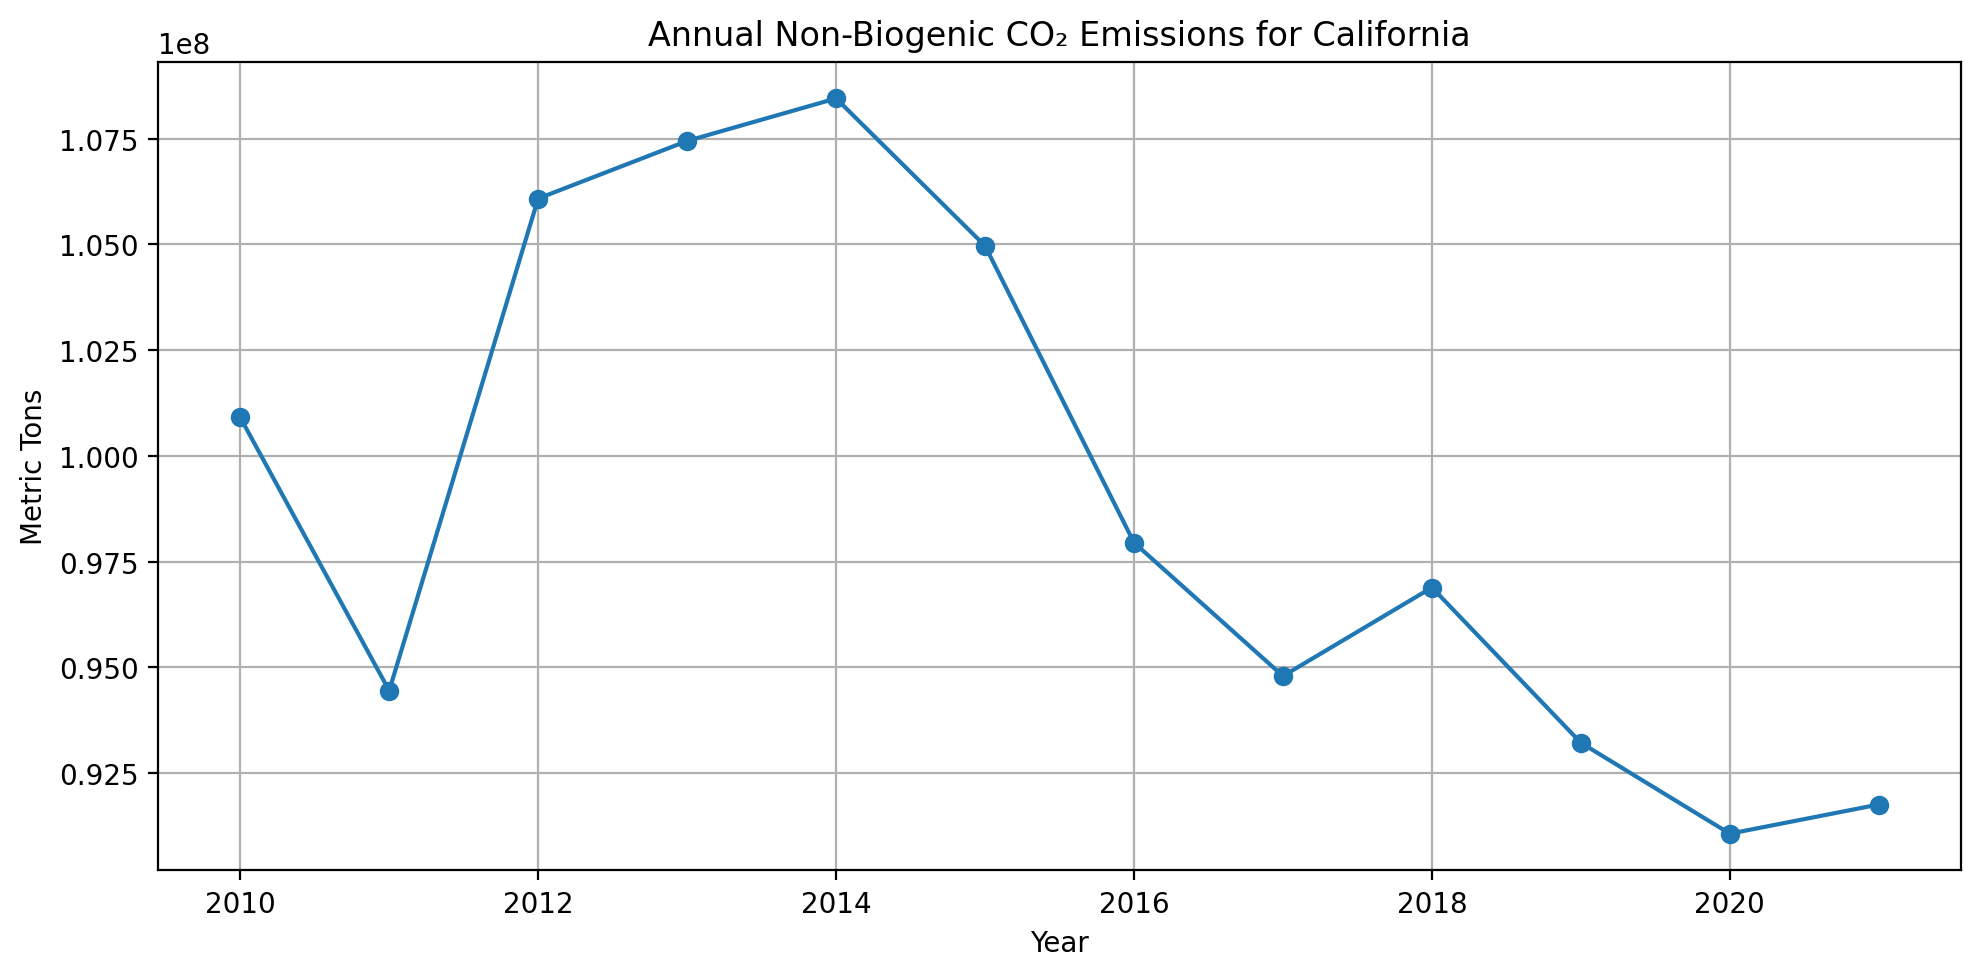

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Retrieve the raw time series again
emissions_data = dc.get_stat_series('geoId/06', 'Annual_Emissions_CarbonDioxide_NonBiogenic')

# Convert to a pandas Series and sort by year
emissions_series = pd.Series(emissions_data)
emissions_series = emissions_series.sort_index()

# Plot the result
plt.figure(figsize=(10, 5))
emissions_series.plot(kind='line', marker='o')
plt.title('Annual Non-Biogenic CO₂ Emissions for California')
plt.xlabel('Year')
plt.ylabel('Metric Tons')
plt.grid(True)
plt.tight_layout()
plt.show()


### 📊 What Does the Chart Show?

This line chart displays the **non-biogenic CO₂ emissions** for California from 2010 to 2021, as reported by the EPA and accessed via Data Commons.

Key observations:
- 📈 Emissions peaked around **2014–2015**, reaching over **108 million metric tons**.
- 📉 There’s a clear **downward trend** after 2015, likely influenced by state policies, energy transitions, and possibly the COVID-19 pandemic in 2020–2021.
- 🔄 Some year-to-year variability still exists, possibly due to natural climate fluctuations, industry activity, or reporting lags.

> ✅ This kind of time-series analysis is possible for many other variables and geographies — just change the `stat_var` or `dcid`!

---

Next, let’s try exploring **nearby places** or dive into **geospatial containment relationships** using other API methods.


### 🗺️ Example: List Counties Within California

We can use `get_places_in()` to find all subregions (e.g., counties) within a given region (e.g., a state).

Let’s list all counties in **California** (`geoId/06`).


In [17]:
california_counties = dc.get_places_in(['geoId/06'], 'County')

# Extract the actual list of counties
county_list = california_counties['geoId/06']

print(f"Total counties: {len(county_list)}")
print("First 10 counties:", county_list[:10])


Total counties: 58
First 10 counties: ['geoId/06001', 'geoId/06003', 'geoId/06005', 'geoId/06007', 'geoId/06009', 'geoId/06011', 'geoId/06013', 'geoId/06015', 'geoId/06017', 'geoId/06019']


### 🗺️ Interpreting the Counties in California

Using `get_places_in(['geoId/06'], 'County')`, we retrieved **58 counties** — which is the correct total for California.

Each result is a **DCID** for a county-level entity, such as:

- `'geoId/06001'` → Alameda County  
- `'geoId/06013'` → Contra Costa County  
- `'geoId/06037'` → Los Angeles County (not shown above, but in full list)

You can use any of these county DCIDs in other API methods — for example:
- View their properties with `get_property_values()`
- Query their emissions or demographic data with `get_stat_series()`

> 📍 These DCIDs follow a consistent pattern: the state prefix `06` followed by the 3-digit FIPS code of the county.


### 🧭 Example: Get Parent Regions of California

What larger regions is California part of?

We can use the property `'containedInPlace'` to find out.


In [18]:
dc.get_property_values(['geoId/06'], 'containedInPlace')


{'geoId/06': ['country/USA', 'usc/PacificDivision']}

### 🧭 Interpreting the Parent Regions of California

The result of this query:

```python
{'geoId/06': ['country/USA', 'usc/PacificDivision']}
```

...tells us that California is part of two larger geographic entities:

* country/USA → the country-level entity for the United States

* usc/PacificDivision → a U.S. Census Division used for regional grouping (includes states like WA, OR, CA)

These "parent" entities can themselves be queried for:

* Their own properties (e.g. name, ISO code)

* Statistical variables (e.g. national emissions, GDP)

* Relationships (e.g. what else is contained in them)

> ✅ This is especially useful when aggregating or navigating across geographic hierarchies — from county → state → division → country.











---

### ✅ You’ve Now Explored All the Core API Methods!

Each of these methods unlocks a different part of the Data Commons Knowledge Graph:

- `get_triples()` → Explore relationships and events
- `get_property_values()` → Fetch static metadata
- `get_stat_series()` → Analyze time series metrics
- `get_places_in()` → Navigate geographic hierarchies
- `'containedInPlace'` → Connect entities to parent regions

Up next: let’s **visualize** the network of relationships we've been exploring!


# Section 3. Visualizing the Data Commons Knowledge Graph
## 🧠 Visualizing the Knowledge Graph with NetworkX

Since Data Commons is built as a **Knowledge Graph**, it’s natural to visualize relationships as a network of connected nodes.

We’ll use:
- `get_triples()` to retrieve entity relationships
- `networkx` to build and draw a directed graph

Let’s visualize the relationships of **California** (`geoId/06`) as a graph of triples:  
→ Subject → Predicate → Object





Since the state of Florida is related to 5790 nodes, lets select 15 random nodes to visualize them.

### 🎯 Step 1: Sample a Few Relationship Triples

Since `geoId/06` (California) is related to thousands of nodes, we’ll randomly sample 15 of those relationships to make the graph more readable.

We'll use `random.sample()` to select a subset from the `triples` dictionary.


In [20]:
import random

# Sample 15 triples for California
random.seed(68)
sampled_triples = random.sample(triples[dcid], 15)

# Preview the sampled triples
for s, p, o in sampled_triples:
    print((s, p, o))


('stormEvent/nws1061488', 'affectedPlace', 'geoId/06')
('stormEvent/nws1084497', 'affectedPlace', 'geoId/06')
('floodEvent/2015-08_0x80db650000000000', 'affectedPlace', 'geoId/06')
('stormEvent/nws5380828', 'affectedPlace', 'geoId/06')
('stormEvent/nws5155042', 'affectedPlace', 'geoId/06')
('ipedsId/112561', 'location', 'geoId/06')
('stormEvent/nws1053311', 'affectedPlace', 'geoId/06')
('stormEvent/nws1061511', 'affectedPlace', 'geoId/06')
('nces/00074833', 'containedInPlace', 'geoId/06')
('wikidataId/Q6488611', 'containedInPlace', 'geoId/06')
('stormEvent/nws1002639', 'affectedPlace', 'geoId/06')
('stormEvent/nws1054904', 'affectedPlace', 'geoId/06')
('stormEvent/nws347325', 'affectedPlace', 'geoId/06')
('stormEvent/nws1015304', 'affectedPlace', 'geoId/06')
('geoId/06099', 'containedInPlace', 'geoId/06')


### 🔍 What Are We Looking At?

These 15 lines are randomly sampled **triples** related to California (`geoId/06`), each in the format:


```
(subject, predicate, object)
```


Examples include:

- `('stormEvent/nws1050961', 'affectedPlace', 'geoId/06')` → A storm affected California  
- `('geoId/sch0606750', 'containedInPlace', 'geoId/06')` → A school is located within California  
- `('fire/...', 'location', 'geoId/06')` → A fire occurred in California  

> These triples are the **building blocks of the knowledge graph** — and each one is a potential edge in a network.



---

### Step 2: 🎨 Now Let’s Turn These Into a Visual Graph

While lists of triples are useful for logic and analysis, they can be hard to follow at scale. To better **understand how entities are interconnected**, we’ll transform this list into a visual graph.

- Each entity (subject or object) will become a **node**
- Each relationship (predicate) will become a **labeled arrow (edge)**

We’ll use **NetworkX**, a powerful Python library for visualizing graphs, to do this.

Let's get started!


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


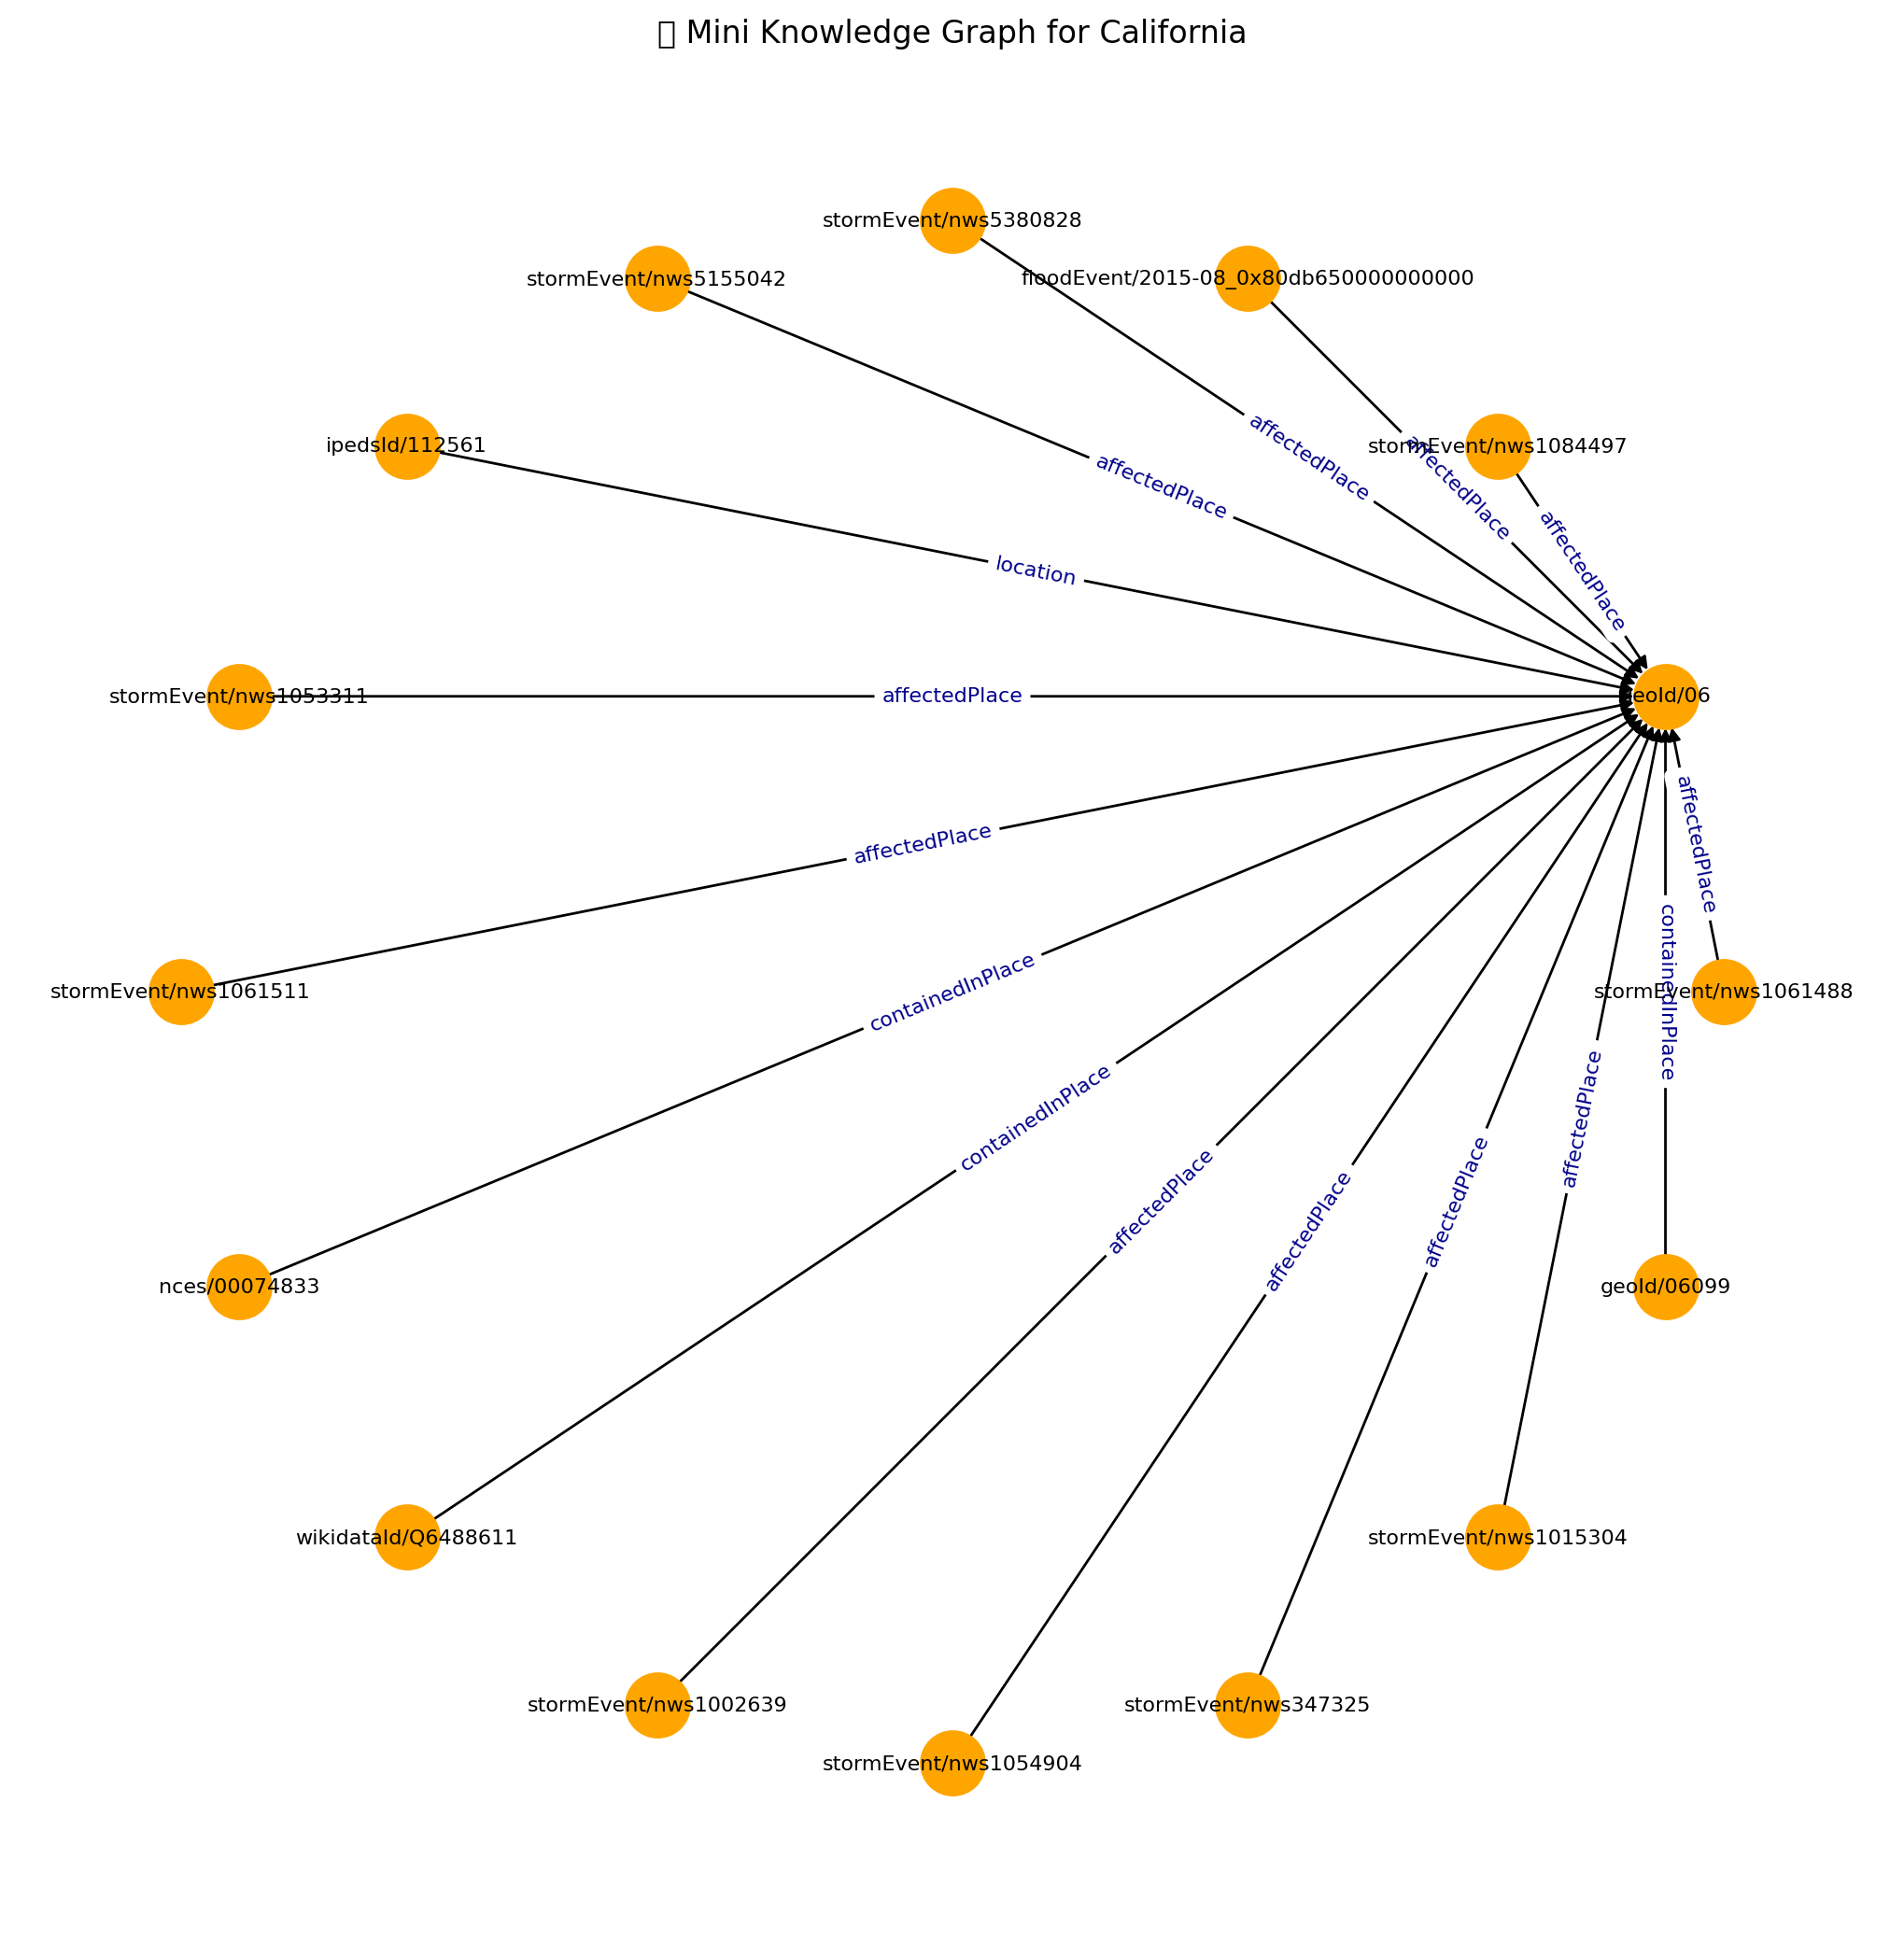

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a directed graph
G = nx.DiGraph()

# Add sampled triples as directed edges
for s, p, o in sampled_triples:
    G.add_edge(s, o, label=p)

# Set layout and size
plt.figure(figsize=(10, 10))
pos = nx.circular_layout(G)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_size=600, node_color="orange", font_size=8)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkblue', font_size=8)

plt.title("📌 Mini Knowledge Graph for California")
plt.axis('off')
plt.show()


### 🔍 Step 3: Interpret What You’re Seeing

Each orange dot is an **entity** connected to `geoId/06` (California) by some relationship.

You’ll notice:
- Many edges are labeled `affectedPlace` — from events like storms or heatwaves
- Others are labeled `containedInPlace` — showing things located inside California
- The central node is usually `geoId/06`

> 💡 You can explore the new entities that appear in this graph by passing their DCIDs into `get_triples()` or `get_property_values()` — just like we did with California.


### 🧪 Step 4: Try Building a Graph for Another State

Pick another state and repeat the same process:

| State          | DCID         |
|----------------|--------------|
| Florida        | `geoId/12`   |
| New York       | `geoId/36`   |
| Texas          | `geoId/48`   |
| Illinois       | `geoId/17`   |
| Ohio           | `geoId/39`   |
| Pennsylvania   | `geoId/42`   |
| North Carolina | `geoId/37`   |
| Michigan       | `geoId/26`   |

Try:
1. Setting `dcid = 'geoId/36'` for New York
2. Re-running `get_triples([dcid])`
3. Sampling and visualizing the triples just like above!

> 🔁 This is a flexible template for exploring *any* entity in the Data Commons knowledge graph.


### Sample whole code for the graph

In [ ]:
# -----------------------------------------------
# Step 1: Set your DCID for a different U.S. state
# (📝 Edit this line!)
dcid = 'geoId/36'  # Example: New York (geoId/36)
# -----------------------------------------------

# Step 2: Get all triples (relationships) for that entity
import datacommons as dc
triples = dc.get_triples([dcid])

# Step 3: Sample a manageable number to visualize
import random
random.seed(42)  # You can change the seed for variety
sampled_triples = random.sample(triples[dcid], 15)

# Preview the relationships
for s, p, o in sampled_triples:
    print((s, p, o))

# -----------------------------------------------
# Step 4: Visualize as a graph with NetworkX
# -----------------------------------------------
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add the sampled triples to the graph
for s, p, o in sampled_triples:
    G.add_edge(s, o, label=p)

# Layout and draw
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=0)  # use spring or circular layout

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=600, node_color="orange", font_size=8)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkblue', font_size=8)

plt.title(f"📌 Mini Knowledge Graph for {dcid}")
plt.axis('off')
plt.tight_layout()
plt.show()


> 🧠 Try changing the `dcid` at the top of the cell to another state from the list above and explore how its connections differ!
> You can also increase the sample size for denser graphs — or filter for specific relationships like `'containedInPlace'`.


###  Step 5: Enhance Node Labels with Readable Names
Let's improve out network to be more readable

---

#### Gather All Unique Node IDs

We first extract all subjects and objects from the sampled triples so we can look up their names.


In [28]:
# Extract all unique nodes from the triples
all_nodes = set()
for s, _, o in sampled_triples:
    all_nodes.update([s, o])


#### Get Names for Each Node

Now we’ll use `dc.get_property_values()` with the `'name'` property to fetch human-readable labels for each node.

In [29]:
# Attempt to fetch the 'name' property for each node
name_map = {}

for node in all_nodes:
    try:
        result = dc.get_property_values([node], 'name')
        name = result.get(node, [node])[0]  # fallback to DCID if no name found
        name_map[node] = name
    except Exception:
        name_map[node] = node  # fallback in case of error


#### Re-draw the Graph Using name_map

We now re-use the original graph code, but use `name_map[node]` for labeling.

Note that names may not be available for some entities such as `stormEvent/`

<ipython-input-30-4f8568ba2ec5>:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


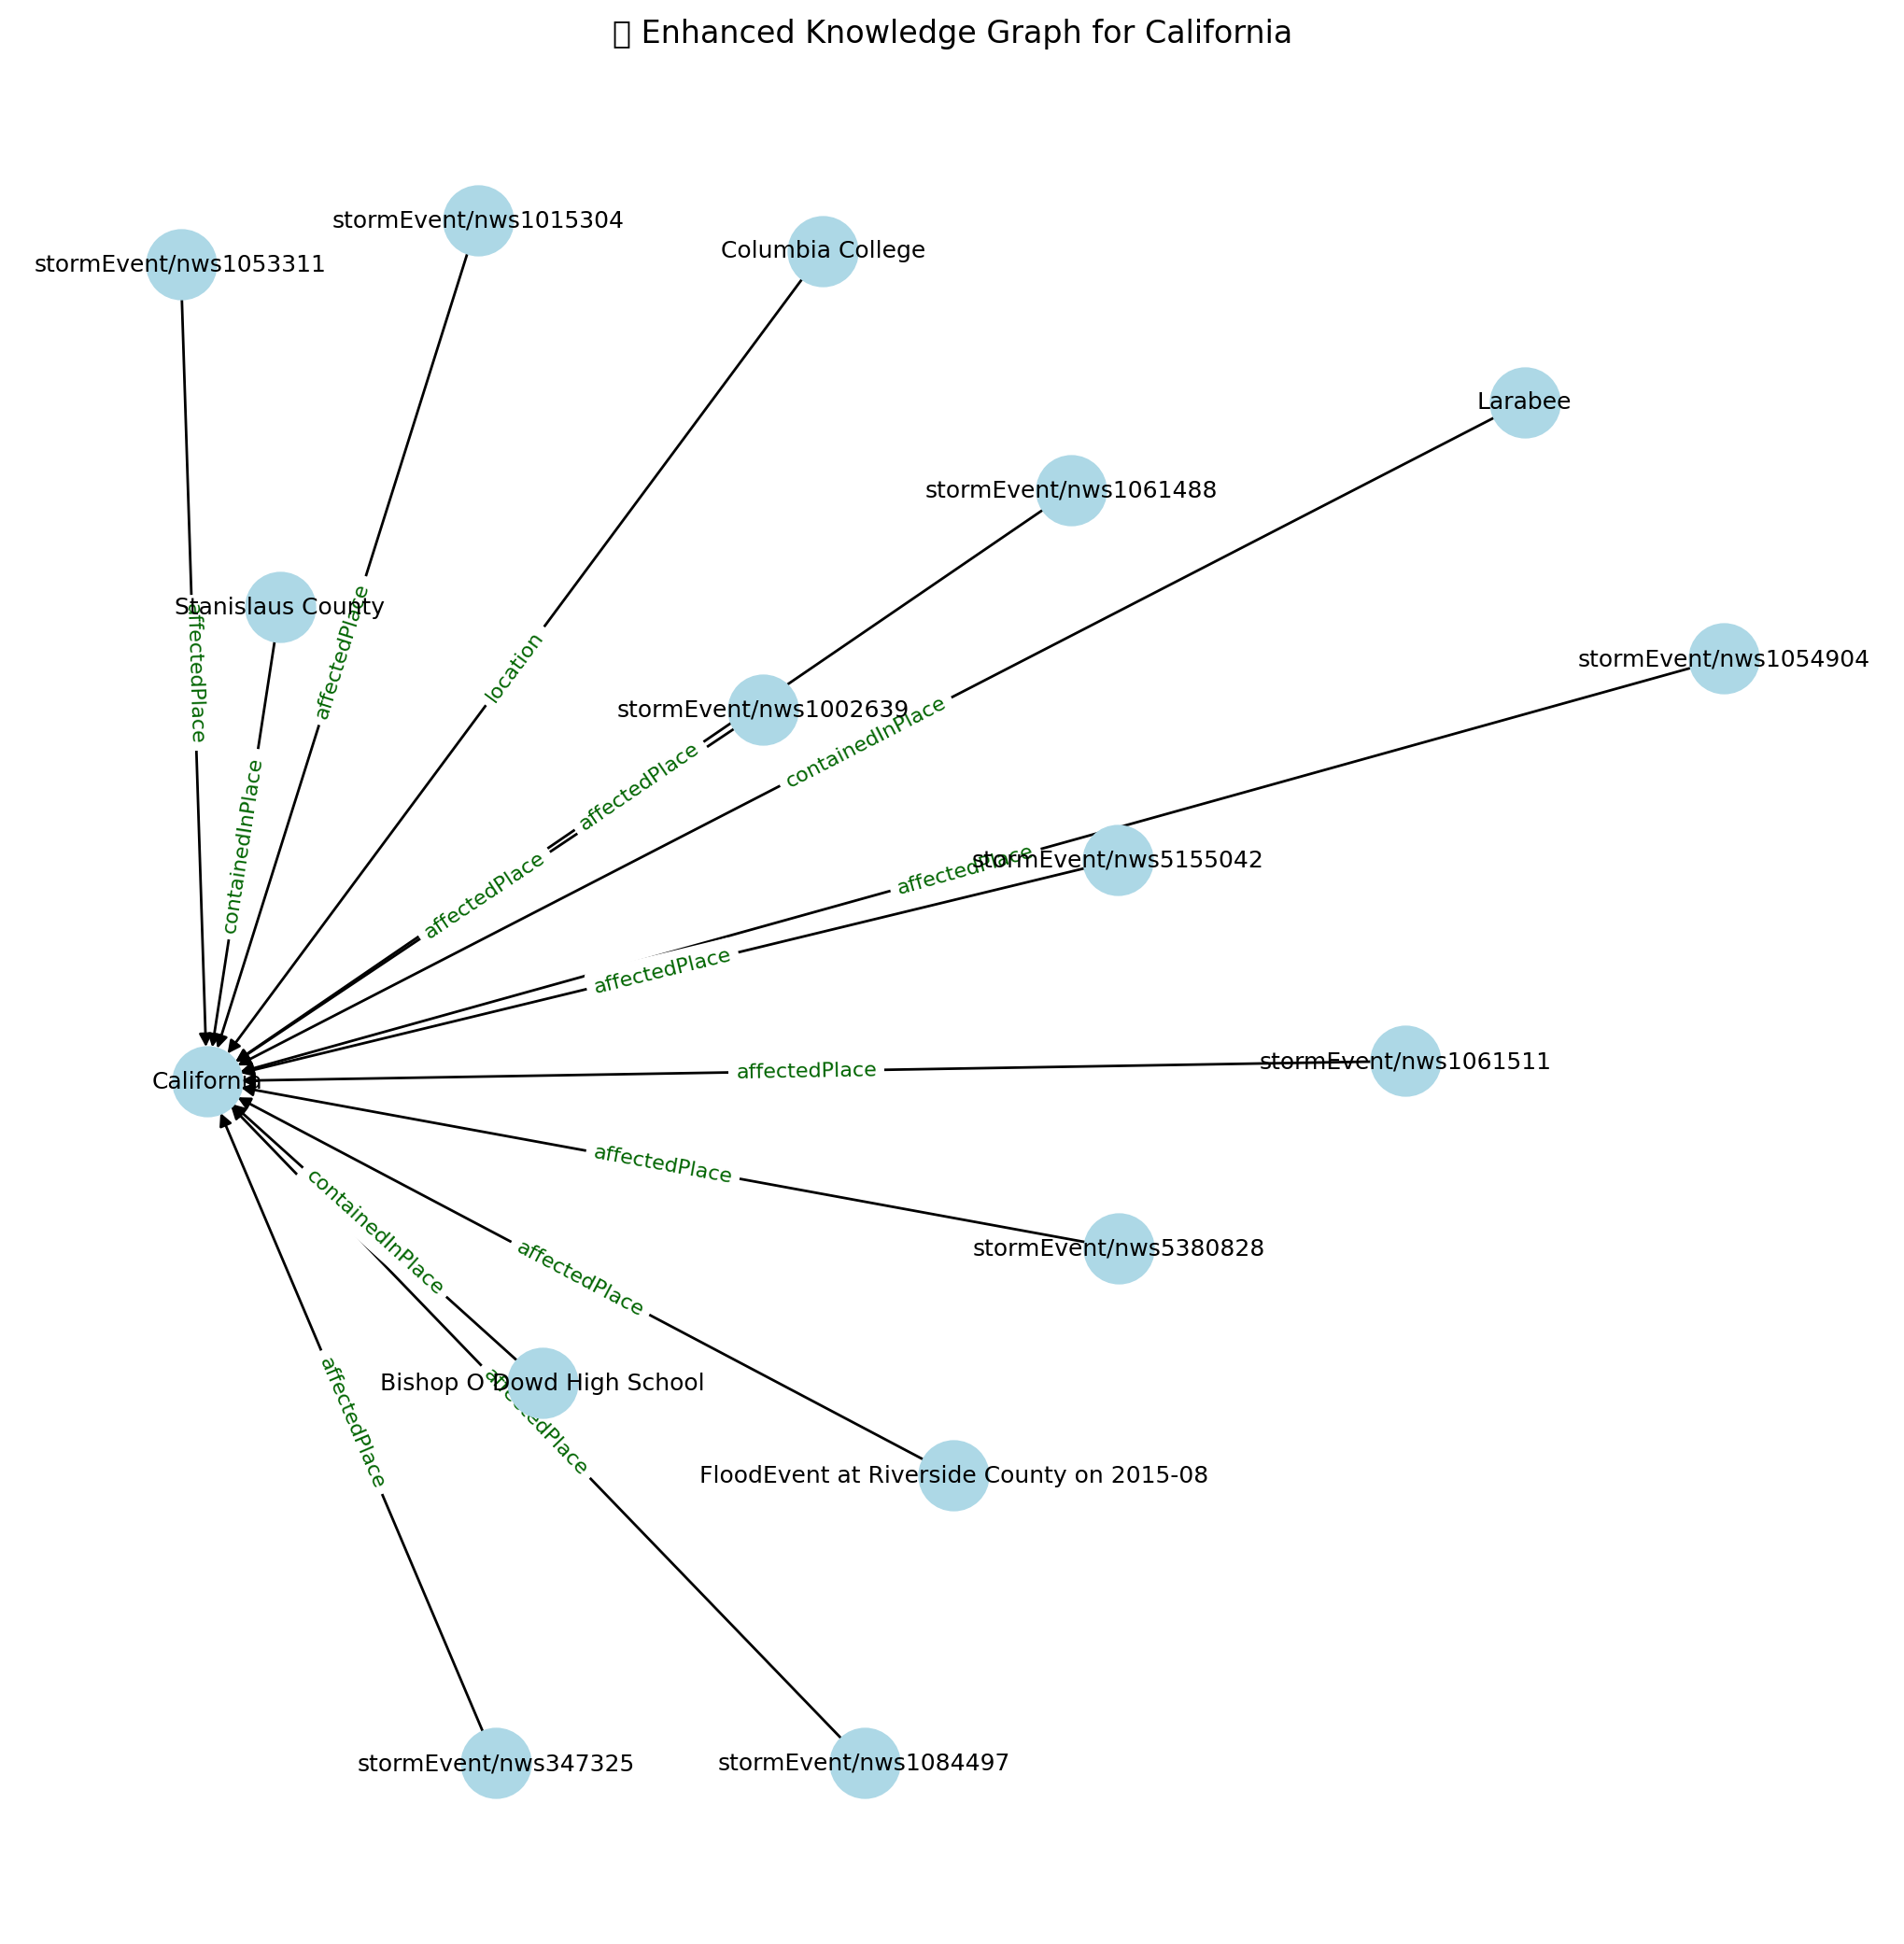

In [30]:
# Build the graph again with enhanced labels
G_named = nx.DiGraph()

for s, p, o in sampled_triples:
    G_named.add_edge(name_map[s], name_map[o], label=p)

# Draw it
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_named, seed=1)

nx.draw(G_named, pos, with_labels=True, node_size=700, node_color="lightblue", font_size=9)
edge_labels = nx.get_edge_attributes(G_named, 'label')
nx.draw_networkx_edge_labels(G_named, pos, edge_labels=edge_labels, font_color='darkgreen', font_size=8)

plt.title(f"🧾 Enhanced Knowledge Graph for {name_map.get(dcid, dcid)}")
plt.axis('off')
plt.tight_layout()
plt.show()


### 🧾 Now with Readable Labels!

This version of the graph replaces raw DCIDs (like `geoId/06`) with human-readable names (like “California”), making the graph much easier to understand.

You can now:
- Quickly spot meaningful relationships
- Recognize named events and organizations
- Follow the structure of the knowledge graph without needing a decoder

> 💡 This technique can be used in larger or multi-hop graphs to preserve clarity.


# ✅ Summary: What We Learned

In this notebook, we explored the core building blocks of the **Google Data Commons Knowledge Graph**, including:

- The structure of a **knowledge graph** (nodes, edges, properties)
- Key Data Commons API methods:
  - `get_triples()` for relationships
  - `get_property_values()` for metadata
  - `get_stat_series()` for time series data
  - `get_places_in()` for geographic hierarchies
- How to **visualize entity relationships** using `NetworkX`
- How to **enhance graphs** with readable names

---

## 🚀 Next Up: Apply Your Skills

Now that you understand the fundamentals, you’re ready to move on to more applied exploration in the next tutorials:

### 📊 [Notebook 2: Building Environmental Time Series](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb)
- Use APIs to retrieve CO₂ and methane emissions data
- Construct and analyze time series by state or sector
- Compare emissions across time and geography

### 🔗 [Notebook 3: Exploring Graph Interconnectivity](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/03_exploring_graphs.ipynb)
- Dive deeper into triple relationships and event data
- Build more complex graph visualizations
- Analyze patterns in storms, fires, and environmental impact

---

> 💡 All notebooks are self-contained, but build on one another conceptually.  
> You can run them in **Colab** or locally using `pip install datacommons`.

---
